In [37]:
from pathlib import Path
import selfmadefunctions
import importlib
import matplotlib.pyplot as plt
import numpy as np
importlib.reload(selfmadefunctions)

# Author: Manou Liesker. Student number: 15250946

Selfmadefuntions imported/reloaded


<module 'selfmadefunctions' from 'c:\\Users\\DTA180363\\Documents\\GitHub\\paperstack\\Manou_version\\code\\selfmadefunctions.py'>

The cell below is used to read and track the videos, and save the y-coordinates into a CSV file (the y coordinates are already normalized). 

Having problems? Look at the outputfolder to see what part of tracking went wrong. Tweak the function accordingly 

(within selfmadefunctions.py there is a variabele named "treshold_value", that's probably the one to tweak. It might be worth it to make treshold_value one of the input parameters instead of a set value within the function).

In [58]:
importlib.reload(selfmadefunctions)

inputfolder = Path(r"Z:\Video_files\Experiments\Raw_Videos\Distance_From_Edge_300t")
outputfolder = Path(r"Z:\Video_files\Experiments\Tracked_Videos\Distance_From_Edge_300t")
csvfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t")

for i in range(7, 8):
    for j in range(2, 3):
        filename = f"20h_300t_{i}cm_{j}.avi"
        print(filename)
        selfmadefunctions.track_video(100, video_inputfolder=inputfolder, 
                                video_outputfolder=outputfolder, 
                                csv_outputfolder=csvfolder, filename=filename, 
                                show=False, save_video=False, save_csv=True, BOTTOM_CROP = 55)

Selfmadefuntions imported/reloaded
20h_300t_7cm_2.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t\20h_300t_7cm_2_clean.csv


The function COR_calculator_general is meant to be able to read a clean csv file, and be given the name of the variable you are changing (such as thickness etc.) to ouput graphs (if Find_Plot = true) to check if everything went right. The function returns the calculated COR.

In [17]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge")

variable_type = "distance from edge"
edge = [i for i in range(2, 16) for _ in range(1, 4)]
COR = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_100t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR.append(cor_value)



avg_cor = []
cor_err = []
x = [i for i in range(2, 16)]


for i in range(14):
    temp_cor = []
    for j in range(3):
        temp_cor.append(COR[3*i + j])
    avg_cor.append(sum(temp_cor)/3)
    cor_err.append(np.std(temp_cor)/np.sqrt(3))

Selfmadefuntions imported/reloaded


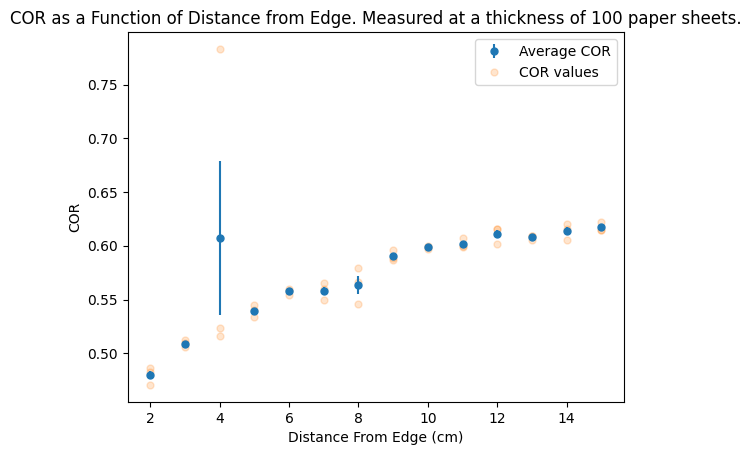

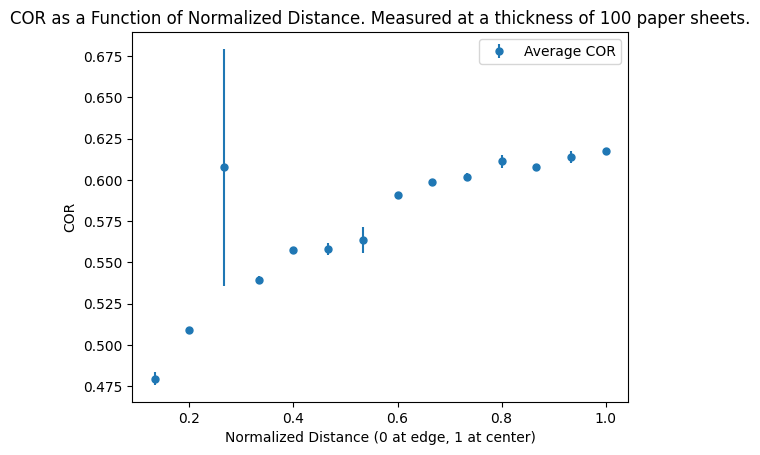

In [18]:
plt.errorbar(x, avg_cor, yerr=cor_err, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.errorbar(edge, COR, fmt = 'o', markersize=5, label='COR values', zorder = 1, alpha = 0.2)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 100 paper sheets.')
plt.legend()
plt.show()

#normalized distance values
normalized_distance = []
for t in x:
    normalized_distance.append(t/15)

plt.errorbar(normalized_distance, avg_cor, yerr=cor_err, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.xlabel('Normalized Distance (0 at edge, 1 at center)')
plt.ylabel('COR')
plt.title('COR as a Function of Normalized Distance. Measured at a thickness of 100 paper sheets.')
plt.legend()
plt.show()


Selfmadefuntions imported/reloaded


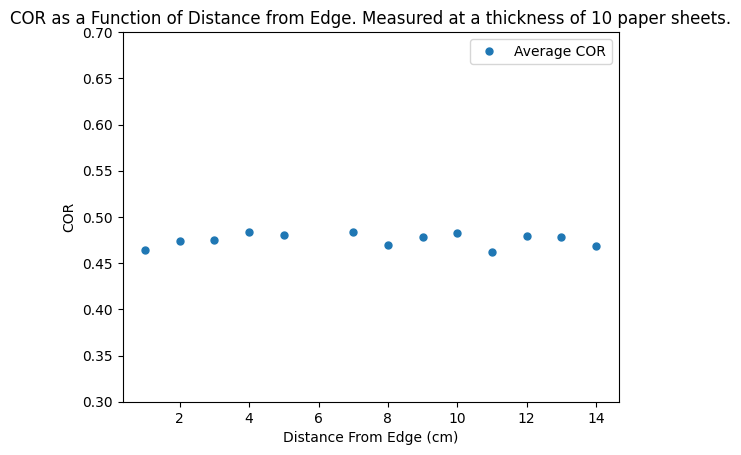

In [19]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_10t")

variable_type = "distance from edge"
x = [i for i in range(1, 15)]
COR = []

for i in range(1, 15):
    variable_value = f"{i} cm"
    
    for j in range(1, 2):
        filename = f"20h_10t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR.append(cor_value)


plt.errorbar(x, COR, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.ylim(0.3, 0.7)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 10 paper sheets.')
plt.legend()
plt.show()

In [61]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t")

variable_type = "distance from edge"
edge_300t = np.repeat(np.arange(2, 16), 3)
COR_300t = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_300t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        print(f"filename = {filename}, COR = {cor_value}")
        COR_300t.append(cor_value)



filename = 20h_300t_2cm_1_clean, COR = 0.31834485196281515
filename = 20h_300t_2cm_2_clean, COR = 0.29639547718874915
filename = 20h_300t_2cm_3_clean, COR = 0.29810703865837135
filename = 20h_300t_3cm_1_clean, COR = 0.2875832284629046
filename = 20h_300t_3cm_2_clean, COR = 0.31211534828360427
filename = 20h_300t_3cm_3_clean, COR = 0.290301408324742
filename = 20h_300t_4cm_1_clean, COR = 0.2831802071114167
filename = 20h_300t_4cm_2_clean, COR = 0.29755244625503424
filename = 20h_300t_4cm_3_clean, COR = 0.28787392892419733
filename = 20h_300t_5cm_1_clean, COR = 0.2865091728976284
filename = 20h_300t_5cm_2_clean, COR = 0.2999321861465072
filename = 20h_300t_5cm_3_clean, COR = 0.2912135123650286
filename = 20h_300t_6cm_1_clean, COR = 0.28011714229945656
filename = 20h_300t_6cm_2_clean, COR = 0.27889154358273016
filename = 20h_300t_6cm_3_clean, COR = 0.29378314541446277
filename = 20h_300t_7cm_1_clean, COR = 0.27834357025008793
filename = 20h_300t_7cm_2_clean, COR = 0.29873976371743327
file

Selfmadefuntions imported/reloaded


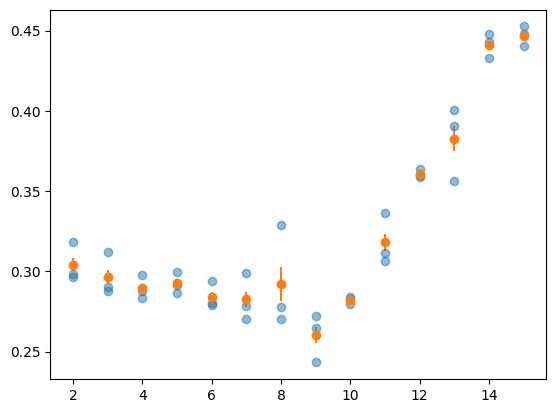

In [64]:
importlib.reload(selfmadefunctions)
x_clean, y_clean, err_y, avg_y, x_unique = selfmadefunctions.get_avg_err(edge_300t, COR_300t)


plt.errorbar(x_clean, y_clean, fmt = 'o', alpha = 0.5)
plt.errorbar(x_unique, avg_y, err_y, fmt = 'o')
plt.show()